# Practical Statistics for Data Scientists - Chapter 5
## Classification

This notebook covers supervised classification techniques including Naive Bayes, Linear Discriminant Analysis (LDA), Logistic Regression (odds ratios, logit link), classification performance evaluation (Confusion Matrix, ROC/AUC, Precision-Recall), and handling imbalanced datasets.

### Environment Setup and Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## 1. Naive Bayes Classifier

Applying Bayes' Theorem with the conditional independence assumption for fast baseline classification.

In [3]:
# Load loan dataset
loan_data = pd.read_csv('drive/MyDrive/Colab Notebooks/data/loan_data.csv')

# Select predictors and binary target (e.g., loan outcome: default vs paid off)
features = ['purpose_', 'home_', 'emp_len_']
X_cat = pd.get_dummies(loan_data[features], drop_first=True)
y = loan_data['outcome']  # Target: 'default' or 'paid off'

# Fit Naive Bayes Model
nb_model = MultinomialNB(alpha=0.01)
nb_model.fit(X_cat, y)

# Class predictions and probabilities
nb_preds = nb_model.predict(X_cat)
nb_probs = nb_model.predict_proba(X_cat)[:, 1]

print(f"Naive Bayes Accuracy: {accuracy_score(y, nb_preds):.4f}")

Naive Bayes Accuracy: 0.5368


---

## 2. Linear Discriminant Analysis (LDA)

Finding linear combinations of continuous variables that maximize class separation.

LDA Linear Coefficients: [[ 4.53307338 -0.07584599]]
LDA Intercept: [-1.6528207]


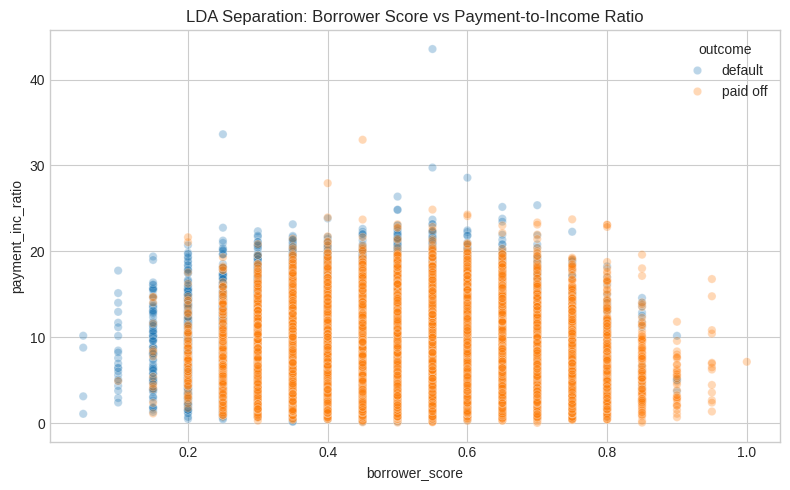

In [4]:
# Select numeric predictors
num_features = ['borrower_score', 'payment_inc_ratio']
X_num = loan_data[num_features]

# Fit LDA
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_num, y)

print("LDA Linear Coefficients:", lda_model.coef_)
print("LDA Intercept:", lda_model.intercept_)

# Plot Decision Boundary
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='borrower_score', y='payment_inc_ratio', hue='outcome', data=loan_data, alpha=0.3, ax=ax)
ax.set_title('LDA Separation: Borrower Score vs Payment-to-Income Ratio')
plt.tight_layout()
plt.show()

---

## 3. Logistic Regression & Odds Ratios

Modeling binary probability outcomes using the logit link function ($\text{logit}(p) = \log(\frac{p}{1-p})$).

In [5]:
# Prepare dataset with binary target (1 = default, 0 = paid off)
loan_data['target'] = (loan_data['outcome'] == 'default').astype(int)

# Fit Logistic Regression using Statsmodels
logit_model = smf.logit('target ~ borrower_score + payment_inc_ratio + purpose_', data=loan_data).fit()
print(logit_model.summary())

# Interpret Coefficients as Odds Ratios
odds_ratios = np.exp(logit_model.params)
print("\nOdds Ratios:")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.635342
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                45342
Model:                          Logit   Df Residuals:                    45333
Method:                           MLE   Df Model:                            8
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                 0.08340
Time:                        06:50:05   Log-Likelihood:                -28808.
converged:                       True   LL-Null:                       -31429.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.3596      0.052     26.366     

---

## 4. Classification Evaluation & ROC Curves

Evaluating binary classifier performance using **Confusion Matrix**, **Precision**, **Recall**, and **Receiver Operating Characteristic (ROC / AUC)**.

Confusion Matrix:
                 Pred Paid Off  Pred Default
Actual Paid Off          14491          8180
Actual Default            8412         14259


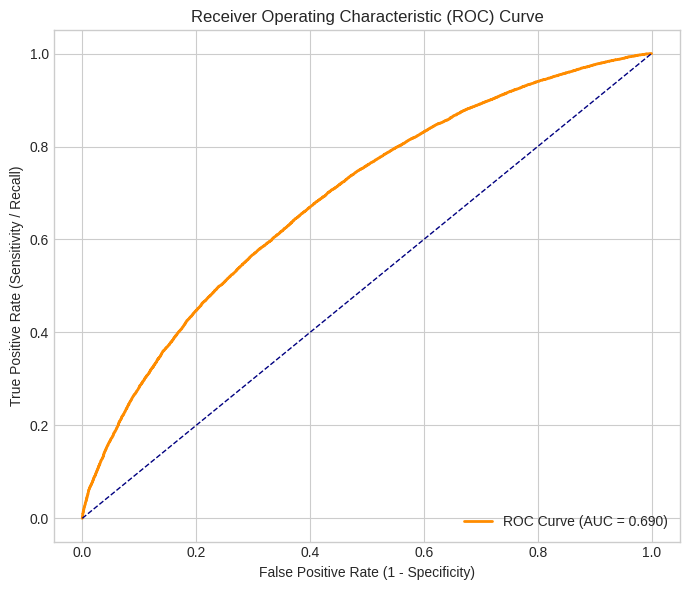

In [6]:
y_true = loan_data['target']
y_pred_probs = logit_model.predict(loan_data)
y_pred_default = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_default)
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=['Actual Paid Off', 'Actual Default'], columns=['Pred Paid Off', 'Pred Default']))

# ROC Curve & AUC Score
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
auc_score = roc_auc_score(y_true, y_pred_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

## 5. Strategies for Imbalanced Datasets

Addressing class imbalance via **Threshold Tuning**, **Undersampling**, **Oversampling**, and **SMOTE** (Synthetic Minority Over-sampling Technique).

In [7]:
# Apply SMOTE Resampling
X_smote = loan_data[['borrower_score', 'payment_inc_ratio']]
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_smote, y_true)

print("Original Class Distribution:", np.bincount(y_true))
print("Resampled Class Distribution (SMOTE):", np.bincount(y_res))

# Train Logistic Regression on SMOTE-balanced data
log_smote = LogisticRegression()
log_smote.fit(X_res, y_res)
smote_preds = log_smote.predict(X_smote)

print("\nClassification Report (SMOTE Trained Model):")
print(classification_report(y_true, smote_preds, target_names=['Paid Off', 'Default']))

Original Class Distribution: [22671 22671]
Resampled Class Distribution (SMOTE): [22671 22671]

Classification Report (SMOTE Trained Model):
              precision    recall  f1-score   support

    Paid Off       0.63      0.63      0.63     22671
     Default       0.63      0.62      0.63     22671

    accuracy                           0.63     45342
   macro avg       0.63      0.63      0.63     45342
weighted avg       0.63      0.63      0.63     45342

